### Library Installation

In [1]:
pip install pandas matplotlib seaborn mlxten

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement mlxten (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for mlxten


### Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("E-Commerce data.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Understand Data

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Data Cleaning

In [6]:
# Remove nulls
df.dropna(inplace=True)

In [7]:
# Remove negative values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [8]:
# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
# Create Sales column
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [10]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Sales  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  


### Save Clean Data

In [11]:
df.to_csv("E-Commerce cleaned data.csv", index=False)

### Data Analysis

In [12]:
#Top Selling Product
top_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Sales, dtype: float64

In [13]:
#Monthly Sales Trend
monthly_sales = df.groupby(df['InvoiceDate'].dt.month)['Sales'].sum()
monthly_sales

InvoiceDate
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: Sales, dtype: float64

In [14]:
#Top Customer
top_customers = df.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False)
top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Sales, dtype: float64

In [15]:
#Country Wise Sales
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64

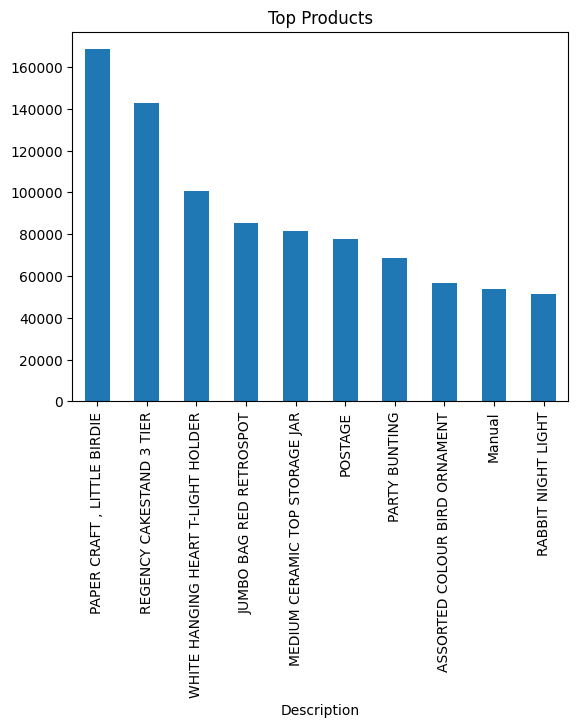

In [16]:
import matplotlib.pyplot as plt
top_products.head(10).plot(kind='bar')
plt.title("Top Products")
plt.show()

### Product Recommendation System

In [17]:
#Create Basket
basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'] \
           .sum().unstack().fillna(0)

In [21]:
#Convert to Binary
basket = basket > 0

In [22]:
#Apply Apriory Algorithm

from mlxtend.frequent_patterns import apriori, association_rules
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_items, metric="lift", min_threshold=1)

In [23]:
rules = rules.sort_values(by='lift', ascending=False)
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
73,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.030002,0.029193,0.021045,0.701439,24.027846,1.0,0.020169,3.251619,0.988024,0.551627,0.692461,0.711163
72,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.029193,0.030002,0.021045,0.720887,24.027846,1.0,0.020169,3.475290,0.987201,0.551627,0.712254,0.711163
71,"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.023527,0.037287,0.021045,0.894495,23.989564,1.0,0.020167,9.124846,0.981405,0.529172,0.890409,0.729447
74,(GREEN REGENCY TEACUP AND SAUCER),"(PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.037287,0.023527,0.021045,0.564399,23.989564,1.0,0.020167,2.241671,0.995432,0.529172,0.553904,0.729447
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030002,0.037287,0.024822,0.827338,22.188466,1.0,0.023703,5.575714,0.984468,0.584498,0.820651,0.746520
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037287,0.030002,0.024822,0.665702,22.188466,1.0,0.023703,2.901595,0.991917,0.584498,0.655362,0.746520
70,"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",(ROSES REGENCY TEACUP AND SAUCER ),0.024822,0.042251,0.021045,0.847826,20.066300,1.0,0.019996,6.293778,0.974350,0.457210,0.841113,0.672955
75,(ROSES REGENCY TEACUP AND SAUCER ),"(PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...",0.042251,0.024822,0.021045,0.498084,20.066300,1.0,0.019996,1.942912,0.992082,0.457210,0.485309,0.672955
62,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.030002,0.042251,0.023527,0.784173,18.559754,1.0,0.022259,4.437569,0.975384,0.482835,0.774651,0.670503
63,(ROSES REGENCY TEACUP AND SAUCER ),(PINK REGENCY TEACUP AND SAUCER),0.042251,0.030002,0.023527,0.556833,18.559754,1.0,0.022259,2.188785,0.987858,0.482835,0.543125,0.670503


In [24]:
#Recommendation Function
def recommend(product):
    result = rules[rules['antecedents'].apply(lambda x: product in x)]
    return result[['consequents', 'confidence']]

recommend("WHITE HANGING HEART T-LIGHT HOLDER")

,consequents,confidence
65,(RED HANGING HEART T-LIGHT HOLDER),0.230847
